In [159]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import datetime
from datetime import date
sns.set()

In [160]:
# !pip install Prophet  

In [161]:
from prophet import Prophet

In [162]:
agri = pd.concat([pd.read_csv('agribora_maize_prices.csv'),  pd.read_csv('agriBORA_maize_prices_weeks_46_to_49.csv')])
agri.head()


,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear
0,Nairobi,2023-10-03,50.00,Dry_White_Maize,2023-40,40
1,Kirinyaga,2023-10-03,48.89,Dry_White_Maize,2023-40,40
2,Kisumu,2023-10-03,44.44,Dry_White_Maize,2023-40,40
3,Uasin-Gishu,2023-10-03,46.67,Dry_White_Maize,2023-40,40
4,Uasin-Gishu,2023-10-03,46.67,Dry_White_Maize,2023-40,40


In [163]:
agri['date'] = pd.to_datetime(agri['Date'])
year = agri['date'].dt.isocalendar().year
week = agri['date'].dt.isocalendar().week
week_of_year = year.astype(int).astype(str) + '-' + week.astype(int).astype(str).str.zfill(2)
agri['year_week'] = pd.to_datetime(week_of_year + '-1', format='%G-%V-%u')

In [164]:
agri.head()

,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear,date,year_week
0,Nairobi,2023-10-03,50.00,Dry_White_Maize,2023-40,40,2023-10-03,2023-10-02
1,Kirinyaga,2023-10-03,48.89,Dry_White_Maize,2023-40,40,2023-10-03,2023-10-02
2,Kisumu,2023-10-03,44.44,Dry_White_Maize,2023-40,40,2023-10-03,2023-10-02
3,Uasin-Gishu,2023-10-03,46.67,Dry_White_Maize,2023-40,40,2023-10-03,2023-10-02
4,Uasin-Gishu,2023-10-03,46.67,Dry_White_Maize,2023-40,40,2023-10-03,2023-10-02


In [165]:
agri = agri[agri.Year_Week != '2024-00']
agri = agri[agri.Year_Week != '2025-00']

In [166]:
agri.sort_values(by = 'Year_Week', inplace=True)
agri['price_na'] = agri['WholeSale'].isna().astype(int)
agri = agri[agri.WholeSale.notna()]
agri = agri[agri.County.notna()]

In [167]:
agri.columns

Index(['County', 'Date', 'WholeSale', 'Commodity_Classification', 'Year_Week',
       'WeekofYear', 'date', 'year_week', 'price_na'],
      dtype='object')

In [168]:
agri = agri.groupby(['year_week', 'County'])['WholeSale'].agg(['median']).reset_index()

In [169]:
agri.tail(5)

,year_week,County,median
250,2025-12-01,Kiambu,39.44500
251,2025-12-01,Kirinyaga,40.00000
252,2025-12-01,Mombasa,36.11000
253,2025-12-01,Nairobi,37.84875
254,2025-12-01,Uasin-Gishu,33.33400


In [170]:
target_counties = ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]
df = agri[agri["County"].isin(target_counties)].copy()

In [171]:
df.isna().mean()

year_week    0.0
County       0.0
median       0.0
dtype: float64

In [179]:
df = df.rename(columns={'year_week': 'ds', 'median': 'y'})
df['ds'] = pd.to_datetime(df['ds'])


In [180]:
df.County.unique()

array(['Kiambu', 'Kirinyaga', 'Mombasa', 'Nairobi', 'Uasin-Gishu'],
      dtype=object)

In [181]:
df = df.sort_values(['County', 'ds'])

In [182]:
df.shape

(219, 3)

In [183]:
df.County.value_counts()

County
Uasin-Gishu    77
Nairobi        59
Kiambu         34
Kirinyaga      28
Mombasa        21
Name: count, dtype: int64

In [184]:
print(df["County"].nunique())
print(df["County"].value_counts())

5
County
Uasin-Gishu    77
Nairobi        59
Kiambu         34
Kirinyaga      28
Mombasa        21
Name: count, dtype: int64


15:21:04 - cmdstanpy - INFO - Chain [1] start processing
15:21:04 - cmdstanpy - INFO - Chain [1] done processing
15:21:04 - cmdstanpy - INFO - Chain [1] start processing
15:21:04 - cmdstanpy - INFO - Chain [1] done processing
15:21:04 - cmdstanpy - INFO - Chain [1] start processing
15:21:04 - cmdstanpy - INFO - Chain [1] done processing
15:21:04 - cmdstanpy - INFO - Chain [1] start processing
15:21:05 - cmdstanpy - INFO - Chain [1] done processing
15:21:05 - cmdstanpy - INFO - Chain [1] start processing
15:21:05 - cmdstanpy - INFO - Chain [1] done processing


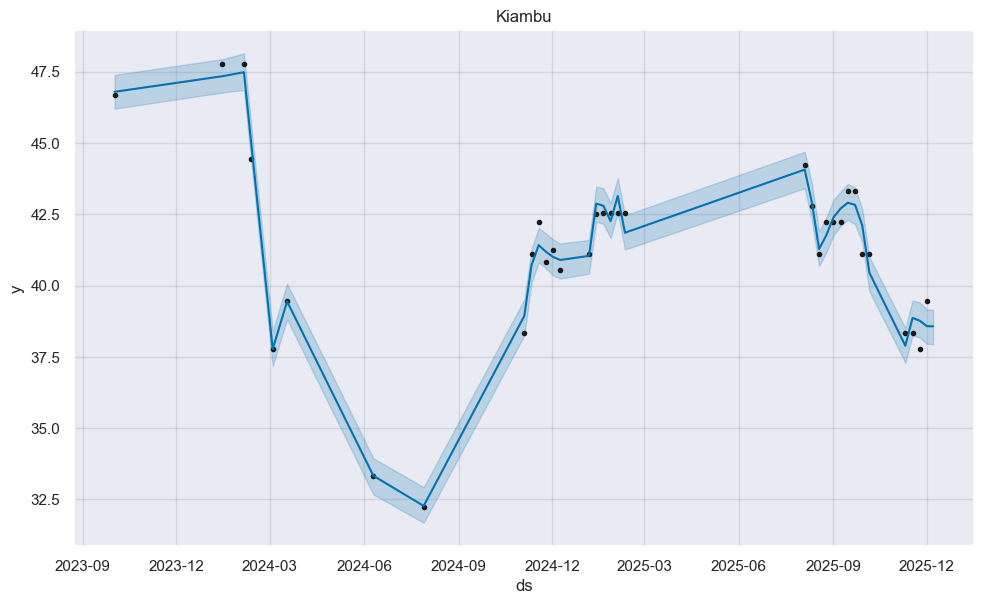

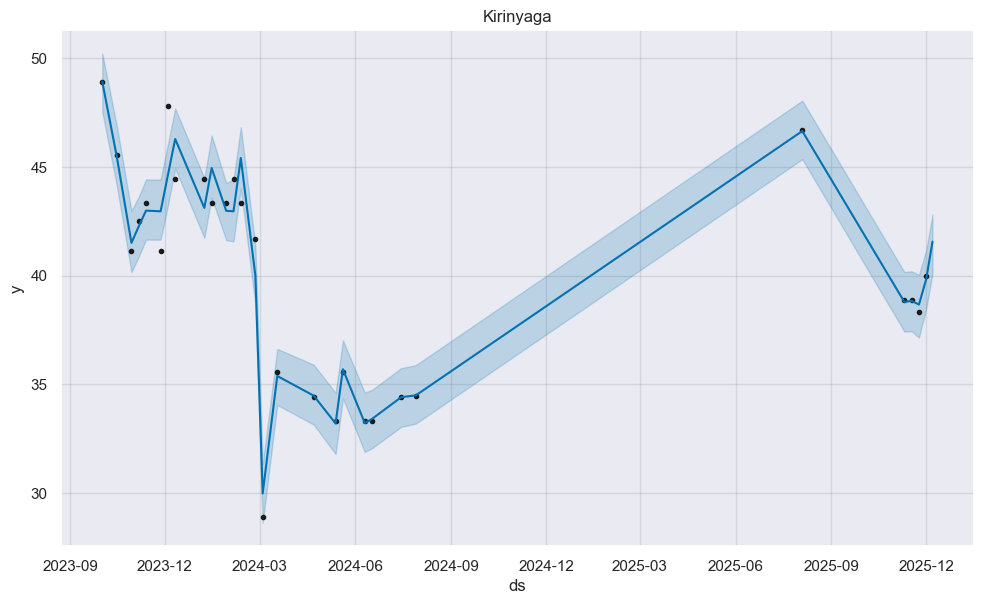

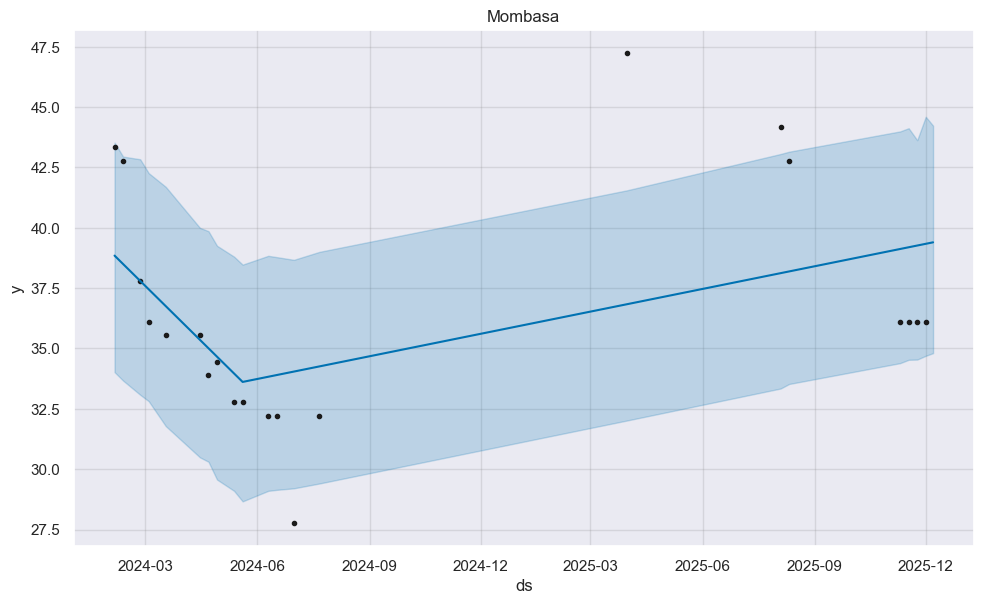

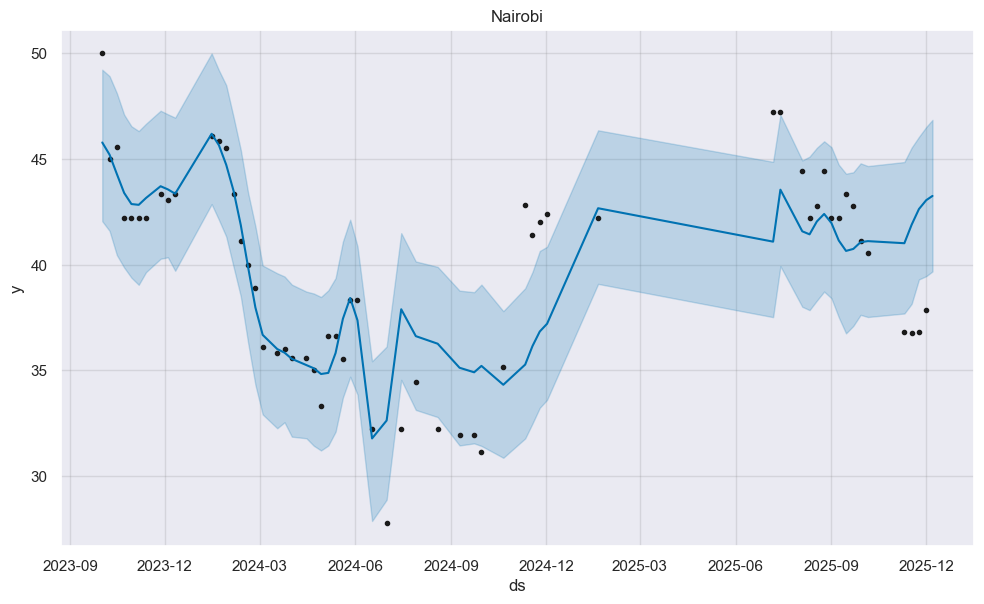

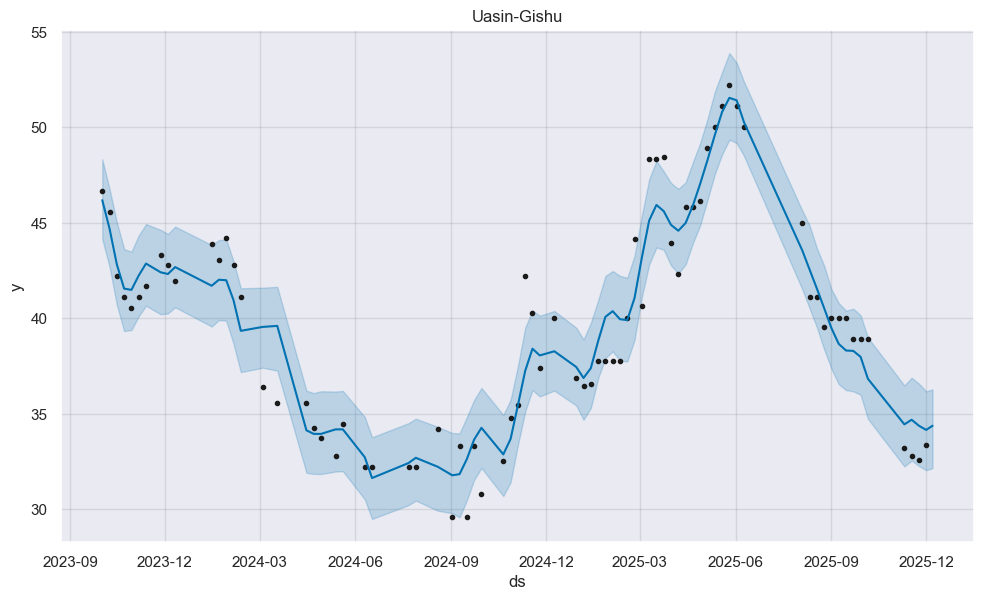

In [228]:
prophet_models = {}
prophet_forecasts = []

for county in target_counties:
    sub = df[df["County"] == county][["ds", "y"]].sort_values("ds")
    m = Prophet(changepoint_range=0.5, changepoint_prior_scale=0.3)
    m.fit(sub)

    future = m.make_future_dataframe(periods=1, freq="W")
    fcst = m.predict(future)
    fig = m.plot(fcst)
    plt.title(county)
    fcst["County"] = county

    prophet_models[county] = m
    prophet_forecasts.append(fcst)
    

prophet_forecasts = pd.concat(prophet_forecasts, ignore_index=True)

In [229]:
prophet_forecasts[prophet_forecasts['ds'] == '2025-12-07']

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,County
34,2025-12-07,-63.013897,37.945421,39.148994,-63.031173,-62.995555,101.584645,101.584645,101.584645,101.584645,101.584645,101.584645,0.0,0.0,0.0,38.570748,Kiambu
63,2025-12-07,47.776859,40.095010,42.815112,47.776859,47.776859,-6.221209,-6.221209,-6.221209,-6.221209,-6.221209,-6.221209,0.0,0.0,0.0,41.555650,Kirinyaga
85,2025-12-07,39.396944,34.806881,44.229569,39.307547,39.494672,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,39.396944,Mombasa
145,2025-12-07,43.294183,39.680022,46.857189,43.278291,43.306309,-0.038945,-0.038945,-0.038945,-0.038945,-0.038945,-0.038945,0.0,0.0,0.0,43.255238,Nairobi
223,2025-12-07,39.735167,32.144257,36.273923,39.680770,39.785921,-5.369343,-5.369343,-5.369343,-5.369343,-5.369343,-5.369343,0.0,0.0,0.0,34.365824,Uasin-Gishu
